# Flow Rate Analysis

This notebook performs a comprehensive statistical analysis of flow rate data from the observations.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.uponor_plots import *

# Set the style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [109]:
# Load the observations data
obs_df = pd.read_csv('data/csv_inputs/data_alamo_real_test.csv')


In [110]:
obs_df['time'] = pd.to_datetime(obs_df['time'])

obs_df.head()

,Unnamed: 0,bed01_stat_actuator,step,bed02_stat_actuator,gym_stat_actuator,kitchen_stat_actuator,living_stat_actuator,upperhall_stat_actuator,time
0,0,0.0,0,1.0,0.0,0.0,0.0,0.0,1970-01-01 00:00:01.736865123
1,1,0.0,1,1.0,0.0,0.0,0.0,0.0,1970-01-01 00:00:01.736865184
2,2,0.0,2,1.0,0.0,0.0,0.0,0.0,1970-01-01 00:00:01.736865246
3,3,1.0,3,1.0,0.0,0.0,0.0,0.0,1970-01-01 00:00:01.736865307
4,4,1.0,4,1.0,0.0,0.0,0.0,0.0,1970-01-01 00:00:01.736865369


In [100]:
def filter_interval_by_timestamp(df, start, end):
    start_timestamp = pd.Timestamp(start)
    end_timestamp = pd.Timestamp(end)
    # Convert 'time' column to datetime if it's not already
    df['datetime'] = pd.to_datetime(df['time'])
    # Filter dataframe by 'time' column using timestamp range
    return df[(df['datetime'] >= start_timestamp) & (df['datetime'] <= end_timestamp)]

#obs_df = add_datetime_column(obs_df)
obs_df = filter_interval_by_timestamp(obs_df, '2022-11-15 00:00:00', '2023-03-15 23:55:00')
#Delete rows in May using datetime column
obs_df = obs_df[obs_df['datetime'].dt.month != 5]

In [111]:

# Filter columns that contain 'flow_rate' in their name
#flow_rate_cols = [col for col in obs_df.columns if 'flow_rate_' in col.lower()]
flow_rate_cols = [col for col in obs_df.columns if 'stat_actuator' in col.lower()]
flow_rate_df = obs_df[flow_rate_cols]

print(f"Found {len(flow_rate_cols)} flow rate columns:")
print(flow_rate_cols)

# Display first few rows of flow rate data
flow_rate_df.head()

Found 6 flow rate columns:
['bed01_stat_actuator', 'bed02_stat_actuator', 'gym_stat_actuator', 'kitchen_stat_actuator', 'living_stat_actuator', 'upperhall_stat_actuator']


,bed01_stat_actuator,bed02_stat_actuator,gym_stat_actuator,kitchen_stat_actuator,living_stat_actuator,upperhall_stat_actuator
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0


In [112]:
# Basic statistics for flow rates
print("Basic Statistics for Flow Rates:")
flow_rate_df.describe()

Basic Statistics for Flow Rates:


,bed01_stat_actuator,bed02_stat_actuator,gym_stat_actuator,kitchen_stat_actuator,living_stat_actuator,upperhall_stat_actuator
count,234846.000000,234846.000000,234846.000000,234846.000000,234846.000000,234846.000000
mean,0.327436,0.348752,0.114909,0.538515,0.123447,0.084941
std,0.469279,0.476576,0.318913,0.498515,0.328950,0.278794
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


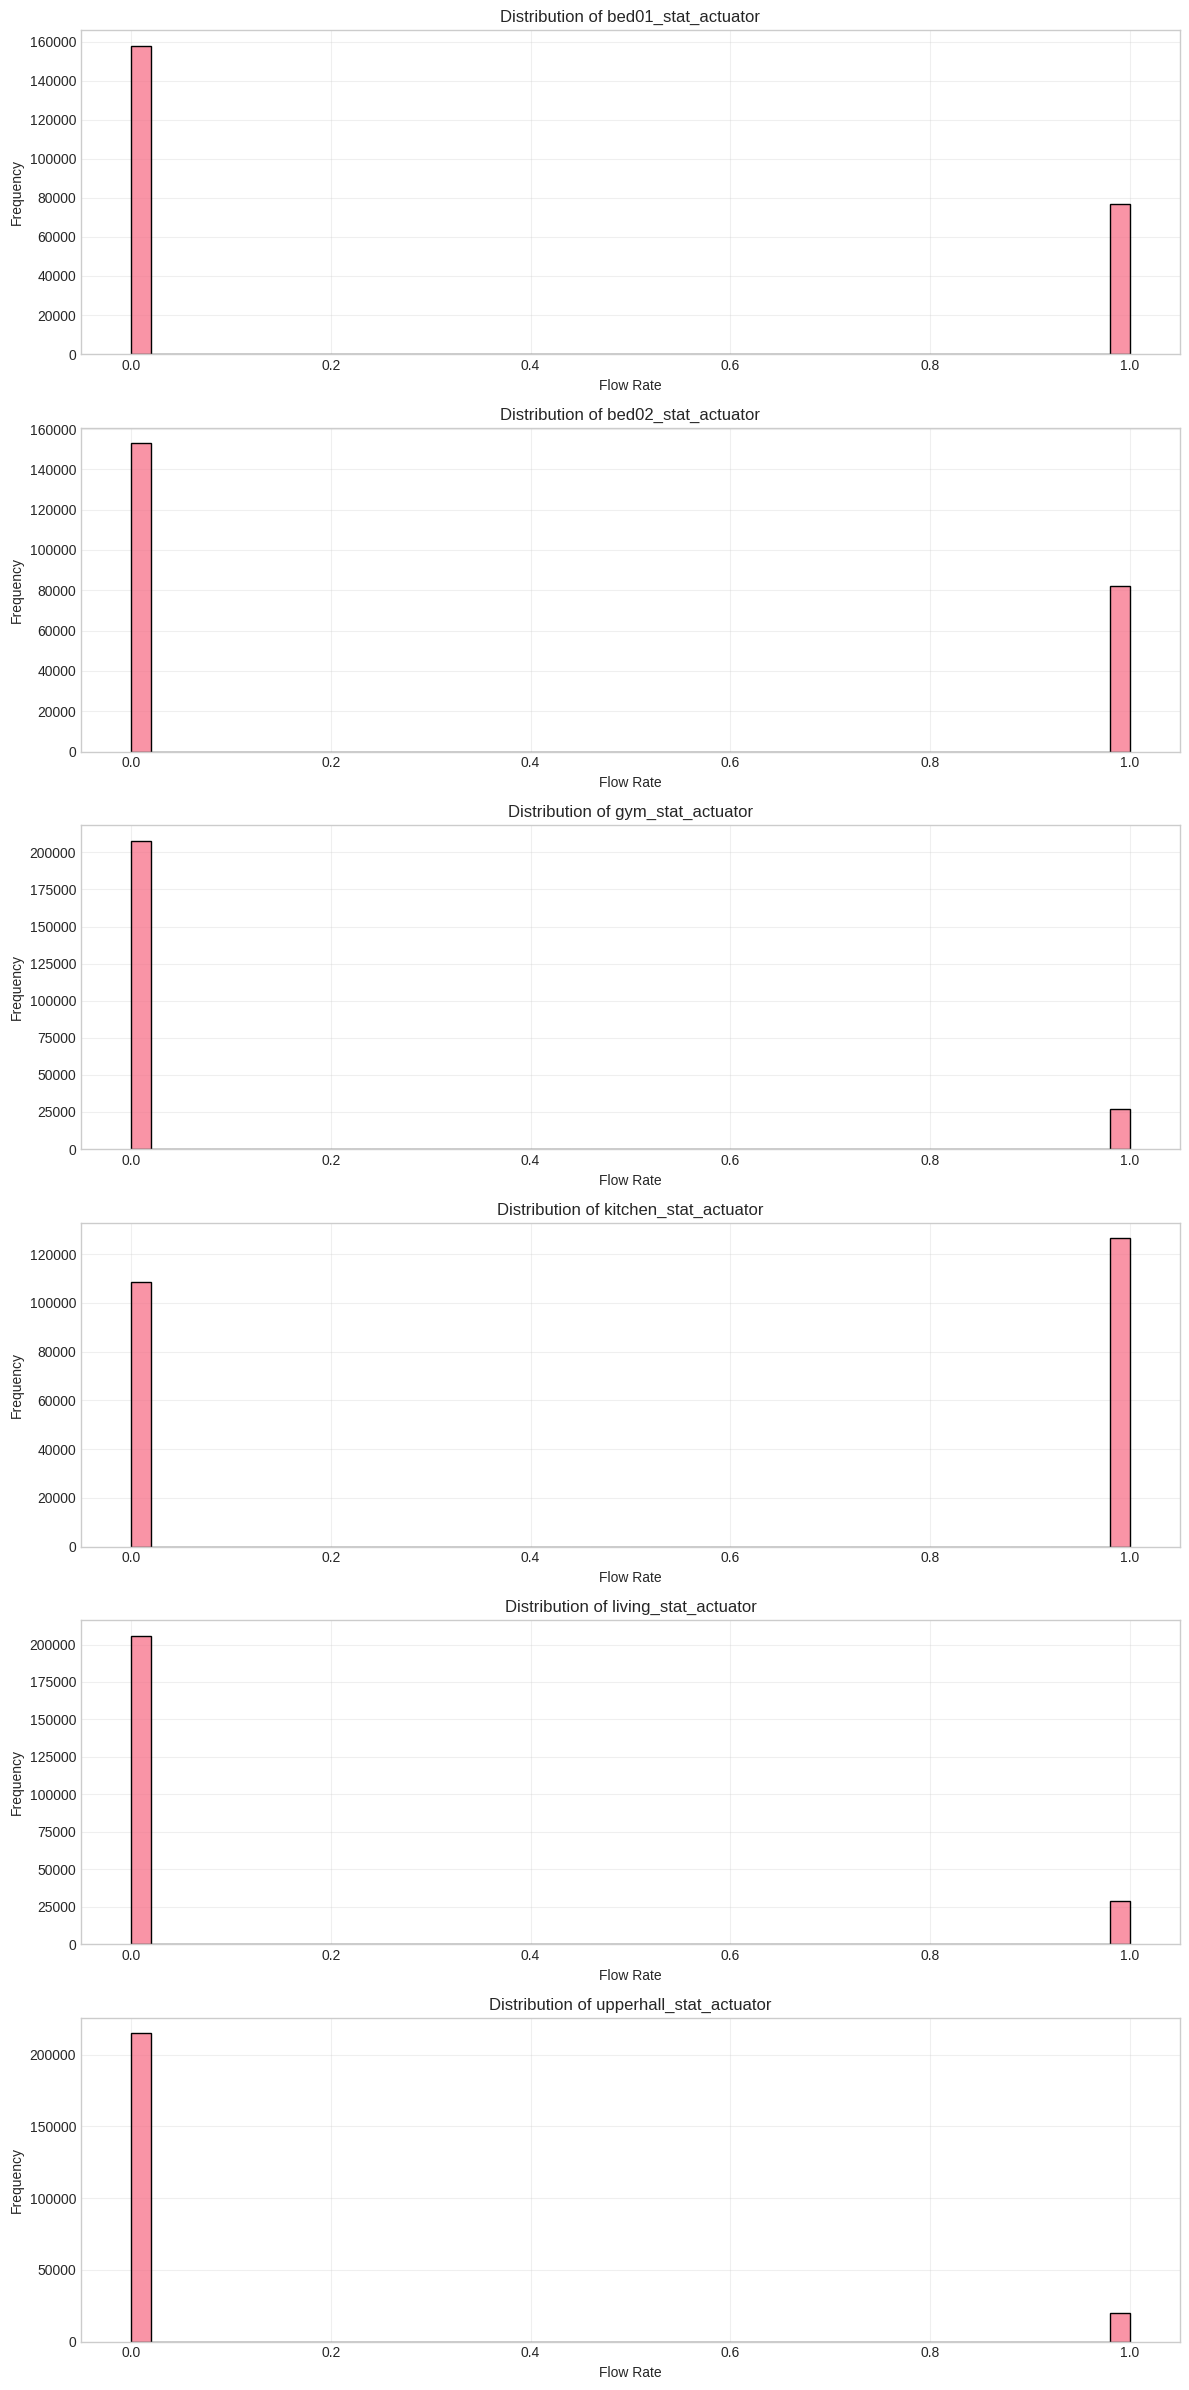

In [113]:
# Create histograms for each flow rate
n_cols = len(flow_rate_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(flow_rate_cols):
    sns.histplot(data=flow_rate_df, x=col, ax=axes[i], bins=50)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Flow Rate')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

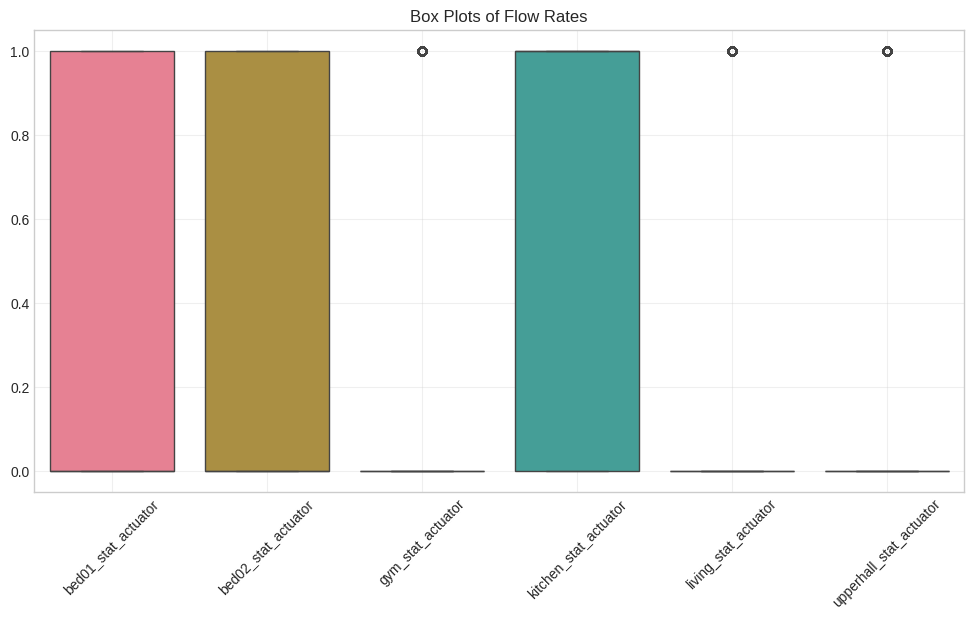

In [114]:
# Create box plots for flow rates
plt.figure(figsize=(12, 6))
sns.boxplot(data=flow_rate_df)
plt.title('Box Plots of Flow Rates')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

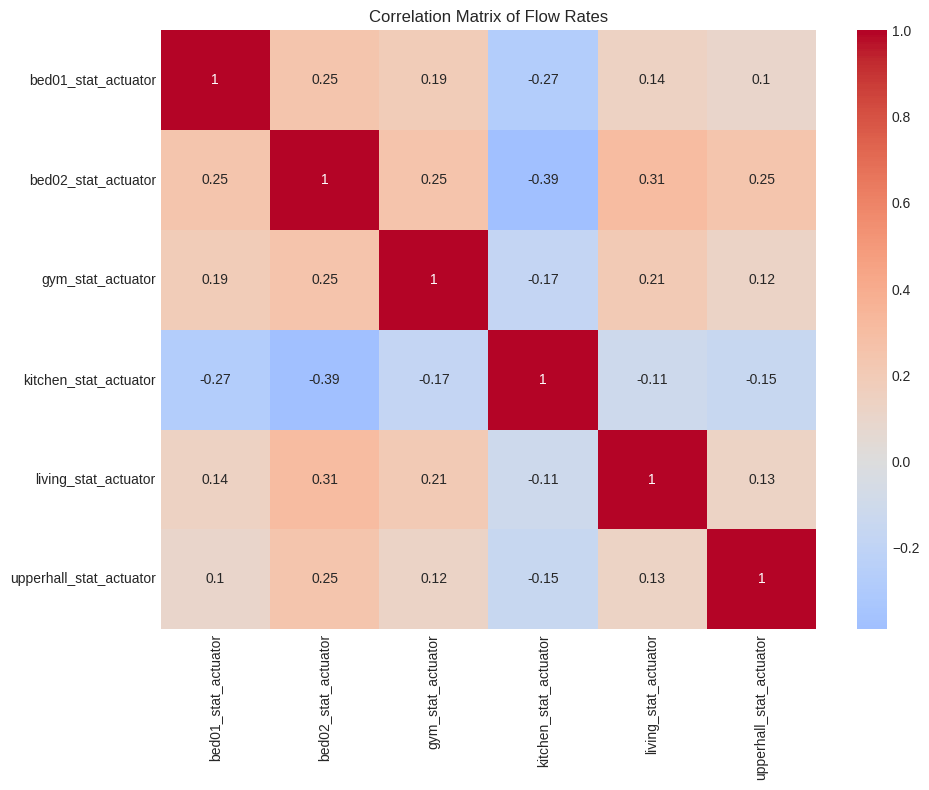

In [115]:
# Calculate correlation matrix for flow rates
correlation_matrix = flow_rate_df.corr()

# Create a heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Flow Rates')
plt.tight_layout()
plt.show()

In [116]:
# Calculate and display additional statistics for each flow rate
print("Additional Statistics for each flow rate:")
for col in flow_rate_cols:
    print(f"\n{col}:")
    print(f"Median: {flow_rate_df[col].median():.2f}")
    print(f"Mode: {flow_rate_df[col].mode().values[0]:.2f}")
    print(f"Standard deviation: {flow_rate_df[col].std():.2f}")
    print(f"Skewness: {flow_rate_df[col].skew():.2f}")
    print(f"Kurtosis: {flow_rate_df[col].kurtosis():.2f}")

Additional Statistics for each flow rate:

bed01_stat_actuator:
Median: 0.00
Mode: 0.00
Standard deviation: 0.47
Skewness: 0.74
Kurtosis: -1.46

bed02_stat_actuator:
Median: 0.00
Mode: 0.00
Standard deviation: 0.48
Skewness: 0.63
Kurtosis: -1.60

gym_stat_actuator:
Median: 0.00
Mode: 0.00
Standard deviation: 0.32
Skewness: 2.42
Kurtosis: 3.83

kitchen_stat_actuator:
Median: 1.00
Mode: 1.00
Standard deviation: 0.50
Skewness: -0.15
Kurtosis: -1.98

living_stat_actuator:
Median: 0.00
Mode: 0.00
Standard deviation: 0.33
Skewness: 2.29
Kurtosis: 3.24

upperhall_stat_actuator:
Median: 0.00
Mode: 0.00
Standard deviation: 0.28
Skewness: 2.98
Kurtosis: 6.87


In [124]:
# Definir las columnas de flow_rate
#flow_rate_columns = ['flow_rate_living', 'flow_rate_kitchen', 'flow_rate_bed1', 'flow_rate_bed2', 'flow_rate_bed3']
flow_rate_columns = ['bed01_stat_actuator', 'bed02_stat_actuator', 'gym_stat_actuator', 'kitchen_stat_actuator', 'living_stat_actuator', 'upperhall_stat_actuator']

# Contar filas donde todas las columnas de flow_rate son 0
rows_all_zero = ((obs_df[flow_rate_columns] == 0) | (obs_df[flow_rate_columns] < 0.01)).all(axis=1).sum()

# Calcular el porcentaje
total_rows = len(obs_df)
percentage = (rows_all_zero / total_rows) * 100

print(f"Número de filas con todas las columnas flow_rate a 0: {rows_all_zero}")
print(f"Total de filas: {total_rows}")
print(f"Porcentaje: {percentage:.2f}%")

Número de filas con todas las columnas flow_rate a 0: 21207
Total de filas: 234846
Porcentaje: 9.03%


In [125]:


# Contar cuántos valores son distintos de cero en cada fila
non_zero_counts = (obs_df[flow_rate_columns] > 0.01).sum(axis=1)

# Contar filas que tienen exactamente 1 valores distintos de cero
rows_with_1_non_zero = (non_zero_counts == 1).sum()
# Contar filas que tienen exactamente 2 valores distintos de cero
rows_with_2_non_zero = (non_zero_counts == 2).sum()
# Contar filas que tienen exactamente 3 valores distintos de cero
rows_with_3_non_zero = (non_zero_counts == 3).sum()
# Contar filas que tienen exactamente 4 valores distintos de cero
rows_with_4_non_zero = (non_zero_counts == 4).sum()
# Contar filas que tienen exactamente 5 valores distintos de cero
rows_with_5_non_zero = (non_zero_counts == 5).sum()

# Calcular el porcentaje
total_rows = len(obs_df)
percentage_1_non_zero = (rows_with_1_non_zero / total_rows) * 100
percentage_2_non_zero = (rows_with_2_non_zero / total_rows) * 100
percentage_3_non_zero = (rows_with_3_non_zero / total_rows) * 100
percentage_4_non_zero = (rows_with_4_non_zero / total_rows) * 100
percentage_5_non_zero = (rows_with_5_non_zero / total_rows) * 100

print(f"Número de filas con exactamente 5 valores distintos de cero: {rows_with_5_non_zero}")
print(f"Total de filas: {total_rows}")
print(f"Porcentaje_1_non_zero: {percentage_1_non_zero:.2f}%")
print(f"Porcentaje_2_non_zero: {percentage_2_non_zero:.2f}%")
print(f"Porcentaje_3_non_zero: {percentage_3_non_zero:.2f}%")
print(f"Porcentaje_4_non_zero: {percentage_4_non_zero:.2f}%")
print(f"Porcentaje_5_non_zero: {percentage_5_non_zero:.2f}%")

Número de filas con exactamente 5 valores distintos de cero: 2876
Total de filas: 234846
Porcentaje_1_non_zero: 52.65%
Porcentaje_2_non_zero: 21.43%
Porcentaje_3_non_zero: 10.72%
Porcentaje_4_non_zero: 4.82%
Porcentaje_5_non_zero: 1.22%


In [126]:

# Crear una columna que indica si todas las columnas flow_rate son cero
obs_df['all_zero'] = (obs_df[flow_rate_columns] < 0.01).all(axis=1)

# Encontrar las posiciones de inicio y fin de cada secuencia
zero_sequences_info = []
current_start = None
current_length = 0

for i, is_zero in enumerate(obs_df['all_zero']):
    if is_zero:
        if current_start is None:
            current_start = i
        current_length += 1
    else:
        if current_start is not None:
            zero_sequences_info.append({
                'start': current_start,
                'end': current_start + current_length - 1,
                'length': current_length
            })
            current_start = None
            current_length = 0

# Si la secuencia termina al final del dataset
if current_start is not None:
    zero_sequences_info.append({
        'start': current_start,
        'end': len(obs_df) - 1,
        'length': current_length
    })

# Crear DataFrame con la información de las secuencias
sequences_df = pd.DataFrame(zero_sequences_info)

if not sequences_df.empty:
    print(f"\nInformación detallada de las secuencias:")
    print(sequences_df)
    
    print(f"\nEstadísticas:")
    print(f"Secuencia más larga: {sequences_df['length'].max()} filas")
    print(f"Secuencia más corta: {sequences_df['length'].min()} filas")
    print(f"Longitud media: {sequences_df['length'].mean():.2f} filas")
    print(f"Longitud mediana: {sequences_df['length'].median():.2f} filas")
else:
    print("No se encontraron secuencias consecutivas de filas con todos los valores cero")


Información detallada de las secuencias:
       start     end  length
0        142     146       5
1        358     361       4
2        387     390       4
3        416     420       5
4        446     449       4
...      ...     ...     ...
3281  186454  186458       5
3282  186484  186487       4
3283  186513  186516       4
3284  186542  186546       5
3285  186572  186575       4

[3286 rows x 3 columns]

Estadísticas:
Secuencia más larga: 768 filas
Secuencia más corta: 1 filas
Longitud media: 6.45 filas
Longitud mediana: 4.00 filas


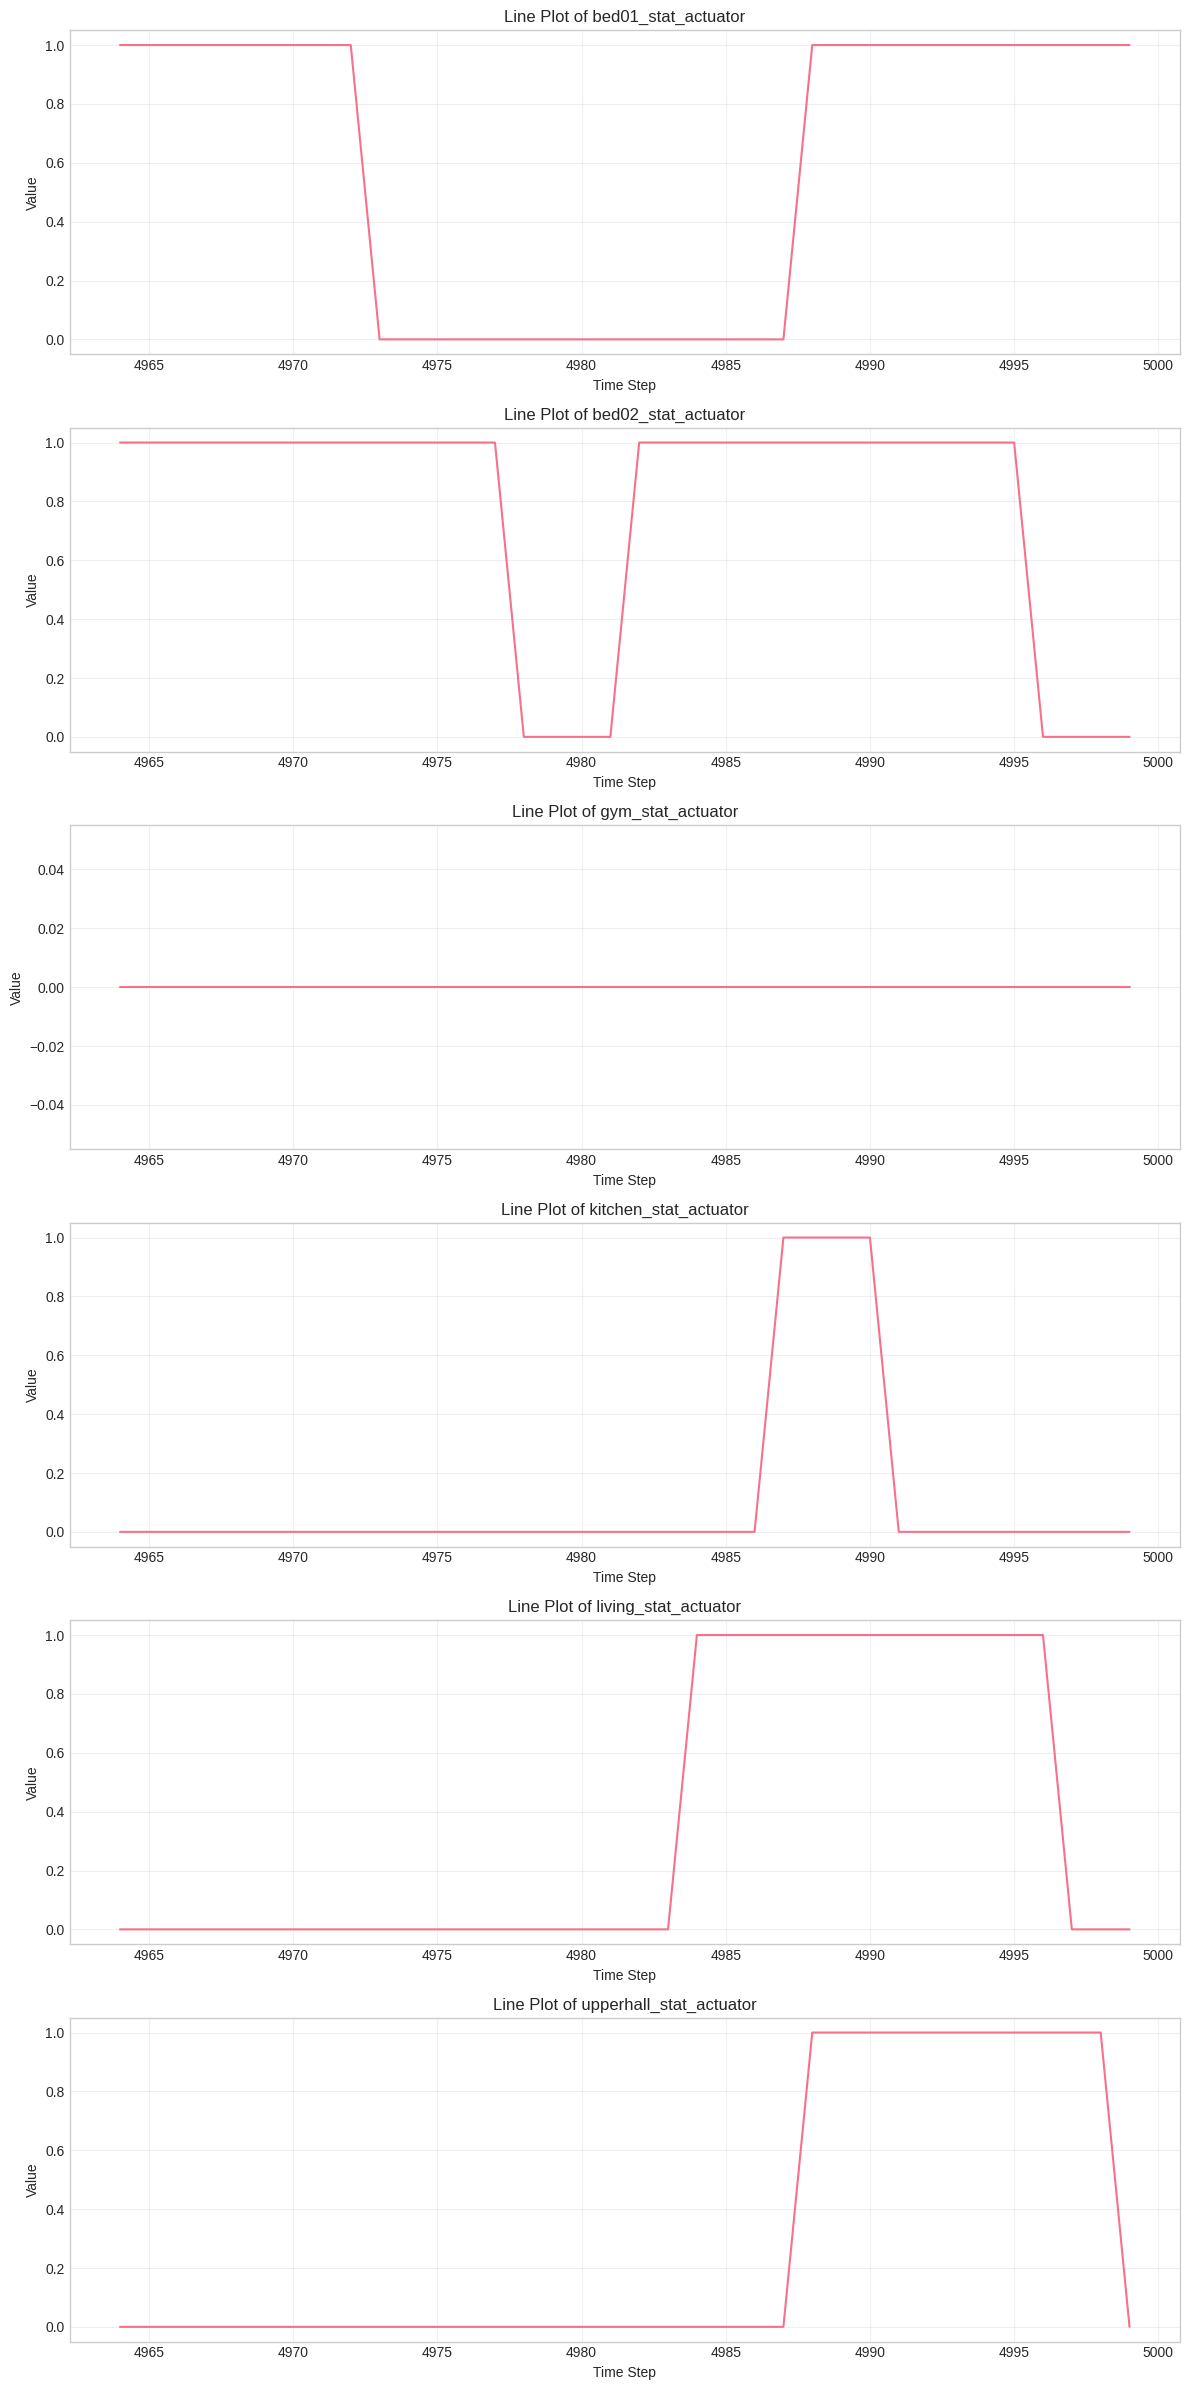

In [127]:
LIMIT = 5000
# Create line plots for each observation
n_cols = len(flow_rate_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(flow_rate_cols):
    axes[i].plot(obs_df[LIMIT-36:LIMIT][col])
    axes[i].set_title(f'Line Plot of {col}')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()